<a href="https://colab.research.google.com/github/fatmayddn/AdaBoost_XGBoost_Karsilastirma/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ─── Temel veri işleme kütüphaneleri ───────────────────────────────────────
import numpy as np          # Sayısal hesaplamalar (dizi işlemleri, lineer cebir)
import pandas as pd         # Tablo (DataFrame) yapısında veri işleme
import matplotlib.pyplot as plt  # Grafik çizimi
import seaborn as sns       # matplotlib üzerine kurulu, daha şık görselleştirme
import warnings
warnings.filterwarnings('ignore')  # Gereksiz uyarıları gizle

# ─── Scikit-learn araçları ──────────────────────────────────────────────────
from sklearn.datasets import make_classification, load_breast_cancer
# load_breast_cancer : 569 örnek, 30 özellik içeren gerçek tıbbi veri seti

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
# train_test_split : veriyi eğitim / test olarak böler
# cross_val_score  : k-fold çapraz doğrulama skoru
# learning_curve   : farklı eğitim boyutlarında performans eğrisi

from sklearn.ensemble import AdaBoostClassifier
# AdaBoost sınıflandırıcı — sklearn içinde hazır gelir

from sklearn.tree import DecisionTreeClassifier
# AdaBoost'un zayıf öğrenicisi olarak kullanılacak karar ağacı

from sklearn.preprocessing import StandardScaler
# Özellikleri ortalaması 0, std'si 1 olacak şekilde ölçekler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

import xgboost as xgb
import time

# ─── Görsel ayarlar ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Tüm kütüphaneler başarıyla yüklendi!')
print(f'   XGBoost versiyonu: {xgb.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi!
   XGBoost versiyonu: 3.4.1


In [ ]:
# ─── Veri setini yükle ──────────────────────────────────────────────────────
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Pandas DataFrame'e çevir (sütun isimlerini de ekle)
X = df.drop(columns=['Churn','customerID'])
y = df['Churn']

X = pd.get_dummies(X, drop_first=True)
y = y.map({'Yes': 1, 'No': 0})

# ─── Veri setini incele ────────────────────────────────────────────────────
print('📋 Veri Seti Bilgileri')
print('='*40)
print(f'Özellik sayısı  : {X.shape[1]}')
print(f'Örnek sayısı    : {X.shape[0]}')
print(f'Sınıf dağılımı  : \n{y.value_counts()}')

# ─── Eğitim / Test olarak böl ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Eğitim seti: {X_train.shape[0]} örnek')
print(f'Test seti  : {X_test.shape[0]} örnek')

X.head()

📋 Veri Seti Bilgileri
Özellik sayısı  : 6559
Örnek sayısı    : 7043
Sınıf dağılımı  : 
Churn
0    5174
1    1869
Name: count, dtype: int64
Eğitim seti: 5634 örnek
Test seti  : 1409 örnek


,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


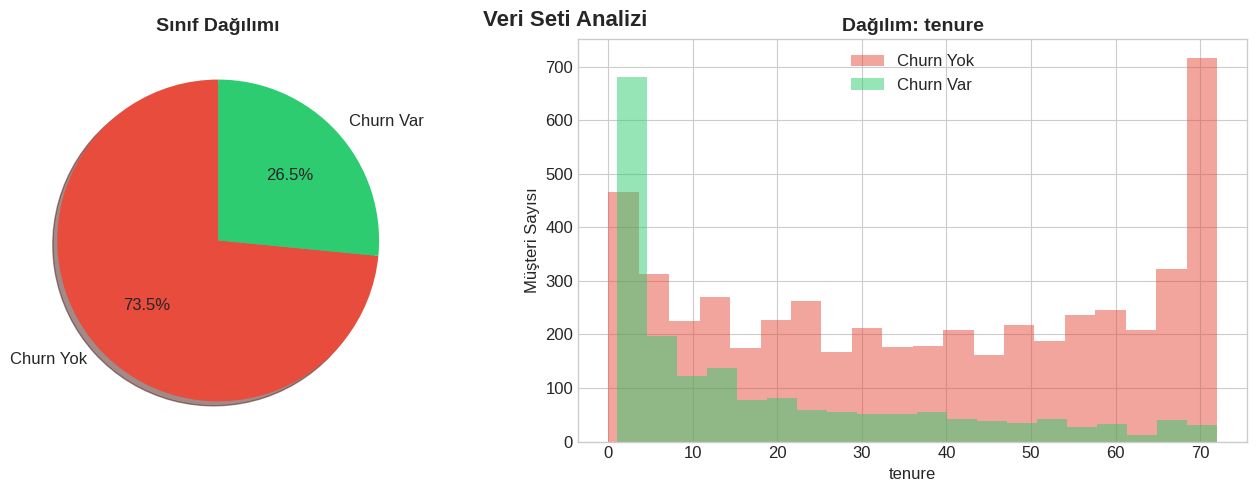

In [ ]:
# ─── Veri setini görselleştir ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = y.value_counts()
labels = ['Churn Yok', 'Churn Var']
colors = ['#e74c3c', '#2ecc71']

axes[0].pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12}
)

axes[0].set_title('Sınıf Dağılımı', fontsize=14, fontweight='bold')

feature = "tenure"

axes[1].hist(X.loc[y==0, feature], alpha=0.5, label='Churn Yok', color='#e74c3c', bins=20)
axes[1].hist(X.loc[y==1, feature], alpha=0.5, label='Churn Var', color='#2ecc71', bins=20)

axes[1].set_title(f'Dağılım: {feature}', fontsize=14, fontweight='bold')
axes[1].set_xlabel(feature)
axes[1].set_ylabel("Müşteri Sayısı")
axes[1].legend()

plt.tight_layout()
plt.suptitle('Veri Seti Analizi', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
print('🔴 ADABOOST MODELİ EĞİTİLİYOR...')
print('='*45)

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    algorithm='SAMME',
    random_state=42
)

start = time.time()
ada_model.fit(X_train, y_train)
ada_time = time.time() - start

ada_pred = ada_model.predict(X_test)
ada_prob = ada_model.predict_proba(X_test)[:, 1]
# Pozitif sınıf = Churn Var

ada_acc    = accuracy_score(y_test, ada_pred)
ada_auc    = roc_auc_score(y_test, ada_prob)
ada_f1     = f1_score(y_test, ada_pred)
ada_prec   = precision_score(y_test, ada_pred)
ada_recall = recall_score(y_test, ada_pred)

print(f'✅ Eğitim Süresi   : {ada_time:.4f} sn')
print(f'📊 Doğruluk (Acc)  : {ada_acc:.4f}  ({ada_acc*100:.2f}%)')
print(f'📊 AUC-ROC         : {ada_auc:.4f}')
print(f'📊 F1 Skoru        : {ada_f1:.4f}')
print(f'📊 Precision       : {ada_prec:.4f}')
print(f'📊 Recall          : {ada_recall:.4f}')
print()
print('📋 Detaylı Rapor:')
print(classification_report(y_test, ada_pred, target_names=['Churn Yok', 'Churn Var']))

🔴 ADABOOST MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi   : 51.0248 sn
📊 Doğruluk (Acc)  : 0.7807  (78.07%)
📊 AUC-ROC         : 0.8336
📊 F1 Skoru        : 0.4432
📊 Precision       : 0.6796
📊 Recall          : 0.3289

📋 Detaylı Rapor:
              precision    recall  f1-score   support

   Churn Yok       0.80      0.94      0.86      1035
   Churn Var       0.68      0.33      0.44       374

    accuracy                           0.78      1409
   macro avg       0.74      0.64      0.65      1409
weighted avg       0.76      0.78      0.75      1409



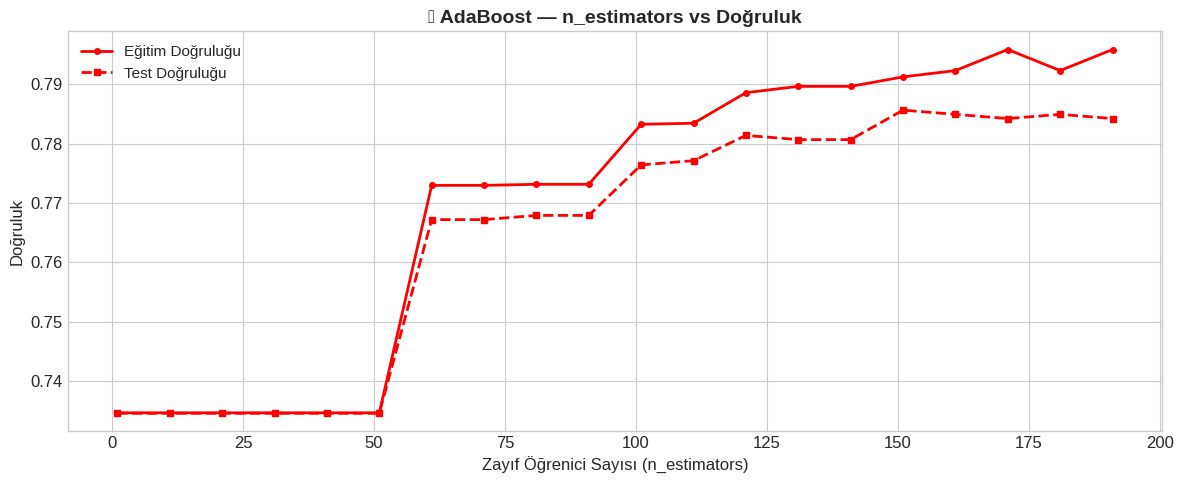

In [ ]:
# ─── n_estimators'a göre performans analizi ─────────────────────────────────
n_estimators_range = range(1, 201, 10)
ada_train_scores = []
ada_test_scores  = []

for n in n_estimators_range:
    m = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        learning_rate=0.1,
        algorithm='SAMME',
        random_state=42
    )
    m.fit(X_train, y_train)
    ada_train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    ada_test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(12, 5))
plt.plot(n_estimators_range, ada_train_scores, 'r-o', markersize=4,
         label='Eğitim Doğruluğu', linewidth=2)
plt.plot(n_estimators_range, ada_test_scores, 'r--s', markersize=4,
         label='Test Doğruluğu', linewidth=2)
plt.xlabel('Zayıf Öğrenici Sayısı (n_estimators)', fontsize=12)
plt.ylabel('Doğruluk', fontsize=12)
plt.title('🔴 AdaBoost — n_estimators vs Doğruluk', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print('🟢 XGBOOST MODELİ EĞİTİLİYOR...')
print('='*45)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

start = time.time()

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
# Pozitif sınıf = Churn Var

xgb_acc    = accuracy_score(y_test, xgb_pred)
xgb_auc    = roc_auc_score(y_test, xgb_prob)
xgb_f1     = f1_score(y_test, xgb_pred)
xgb_prec   = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)

print(f'✅ Eğitim Süresi   : {xgb_time:.4f} sn')
print(f'📊 Doğruluk (Acc)  : {xgb_acc:.4f}  ({xgb_acc*100:.2f}%)')
print(f'📊 AUC-ROC         : {xgb_auc:.4f}')
print(f'📊 F1 Skoru        : {xgb_f1:.4f}')
print(f'📊 Precision       : {xgb_prec:.4f}')
print(f'📊 Recall          : {xgb_recall:.4f}')
print()
print('📋 Detaylı Rapor:')
print(classification_report(y_test, xgb_pred, target_names=['Churn Yok', 'Churn Var']))

🟢 XGBOOST MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi   : 28.6201 sn
📊 Doğruluk (Acc)  : 0.7963  (79.63%)
📊 AUC-ROC         : 0.8478
📊 F1 Skoru        : 0.5773
📊 Precision       : 0.6426
📊 Recall          : 0.5241

📋 Detaylı Rapor:
              precision    recall  f1-score   support

   Churn Yok       0.84      0.89      0.87      1035
   Churn Var       0.64      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



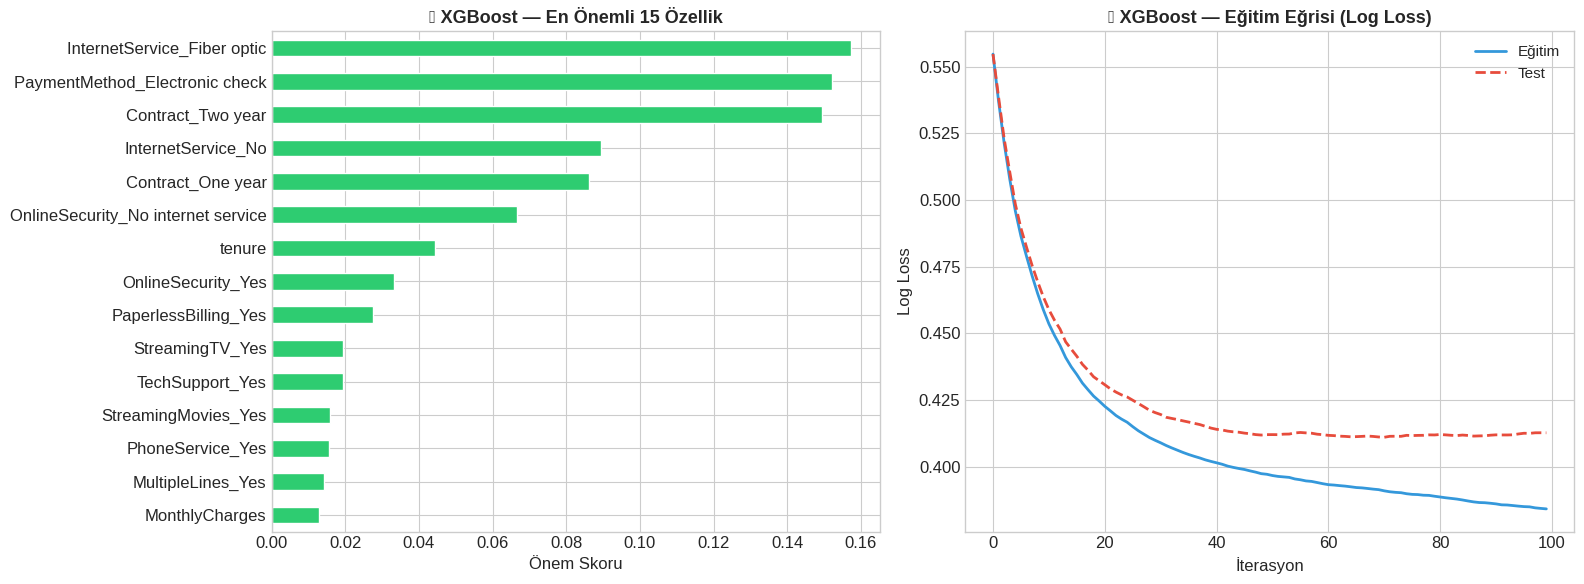

In [ ]:
# ─── XGBoost: Özellik Önemi + Eğitim Eğrisi ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

feat_importance.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('🟢 XGBoost — En Önemli 15 Özellik', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Önem Skoru')

results = xgb_model.evals_result()

axes[1].plot(results['validation_0']['logloss'],
             label='Eğitim', color='#3498db', linewidth=2)
axes[1].plot(results['validation_1']['logloss'],
             label='Test', color='#e74c3c', linewidth=2, linestyle='--')

axes[1].set_title('🟢 XGBoost — Eğitim Eğrisi (Log Loss)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('İterasyon')
axes[1].set_ylabel('Log Loss')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

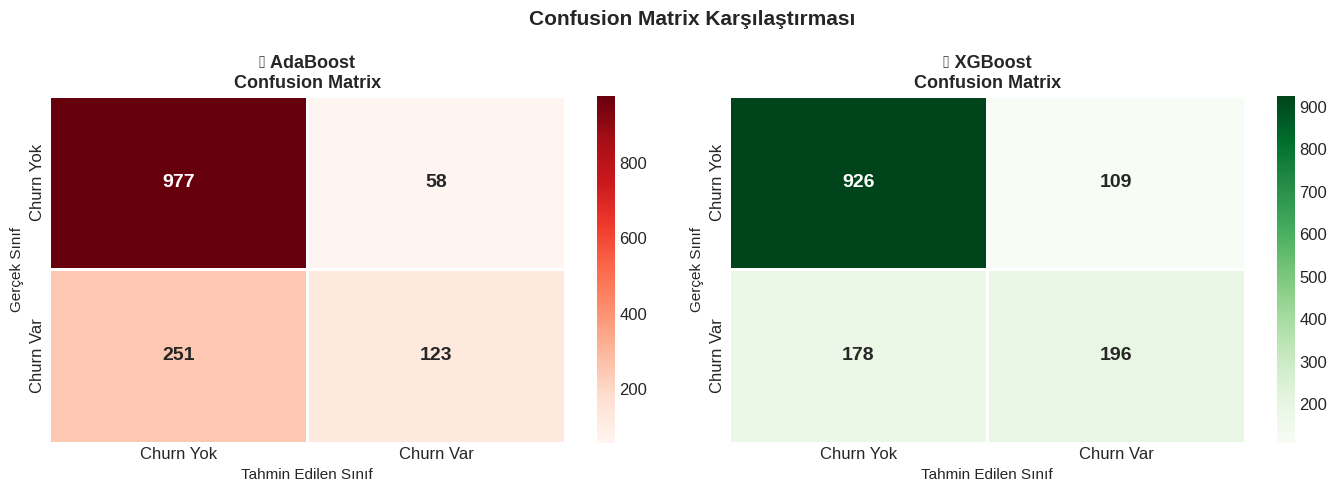

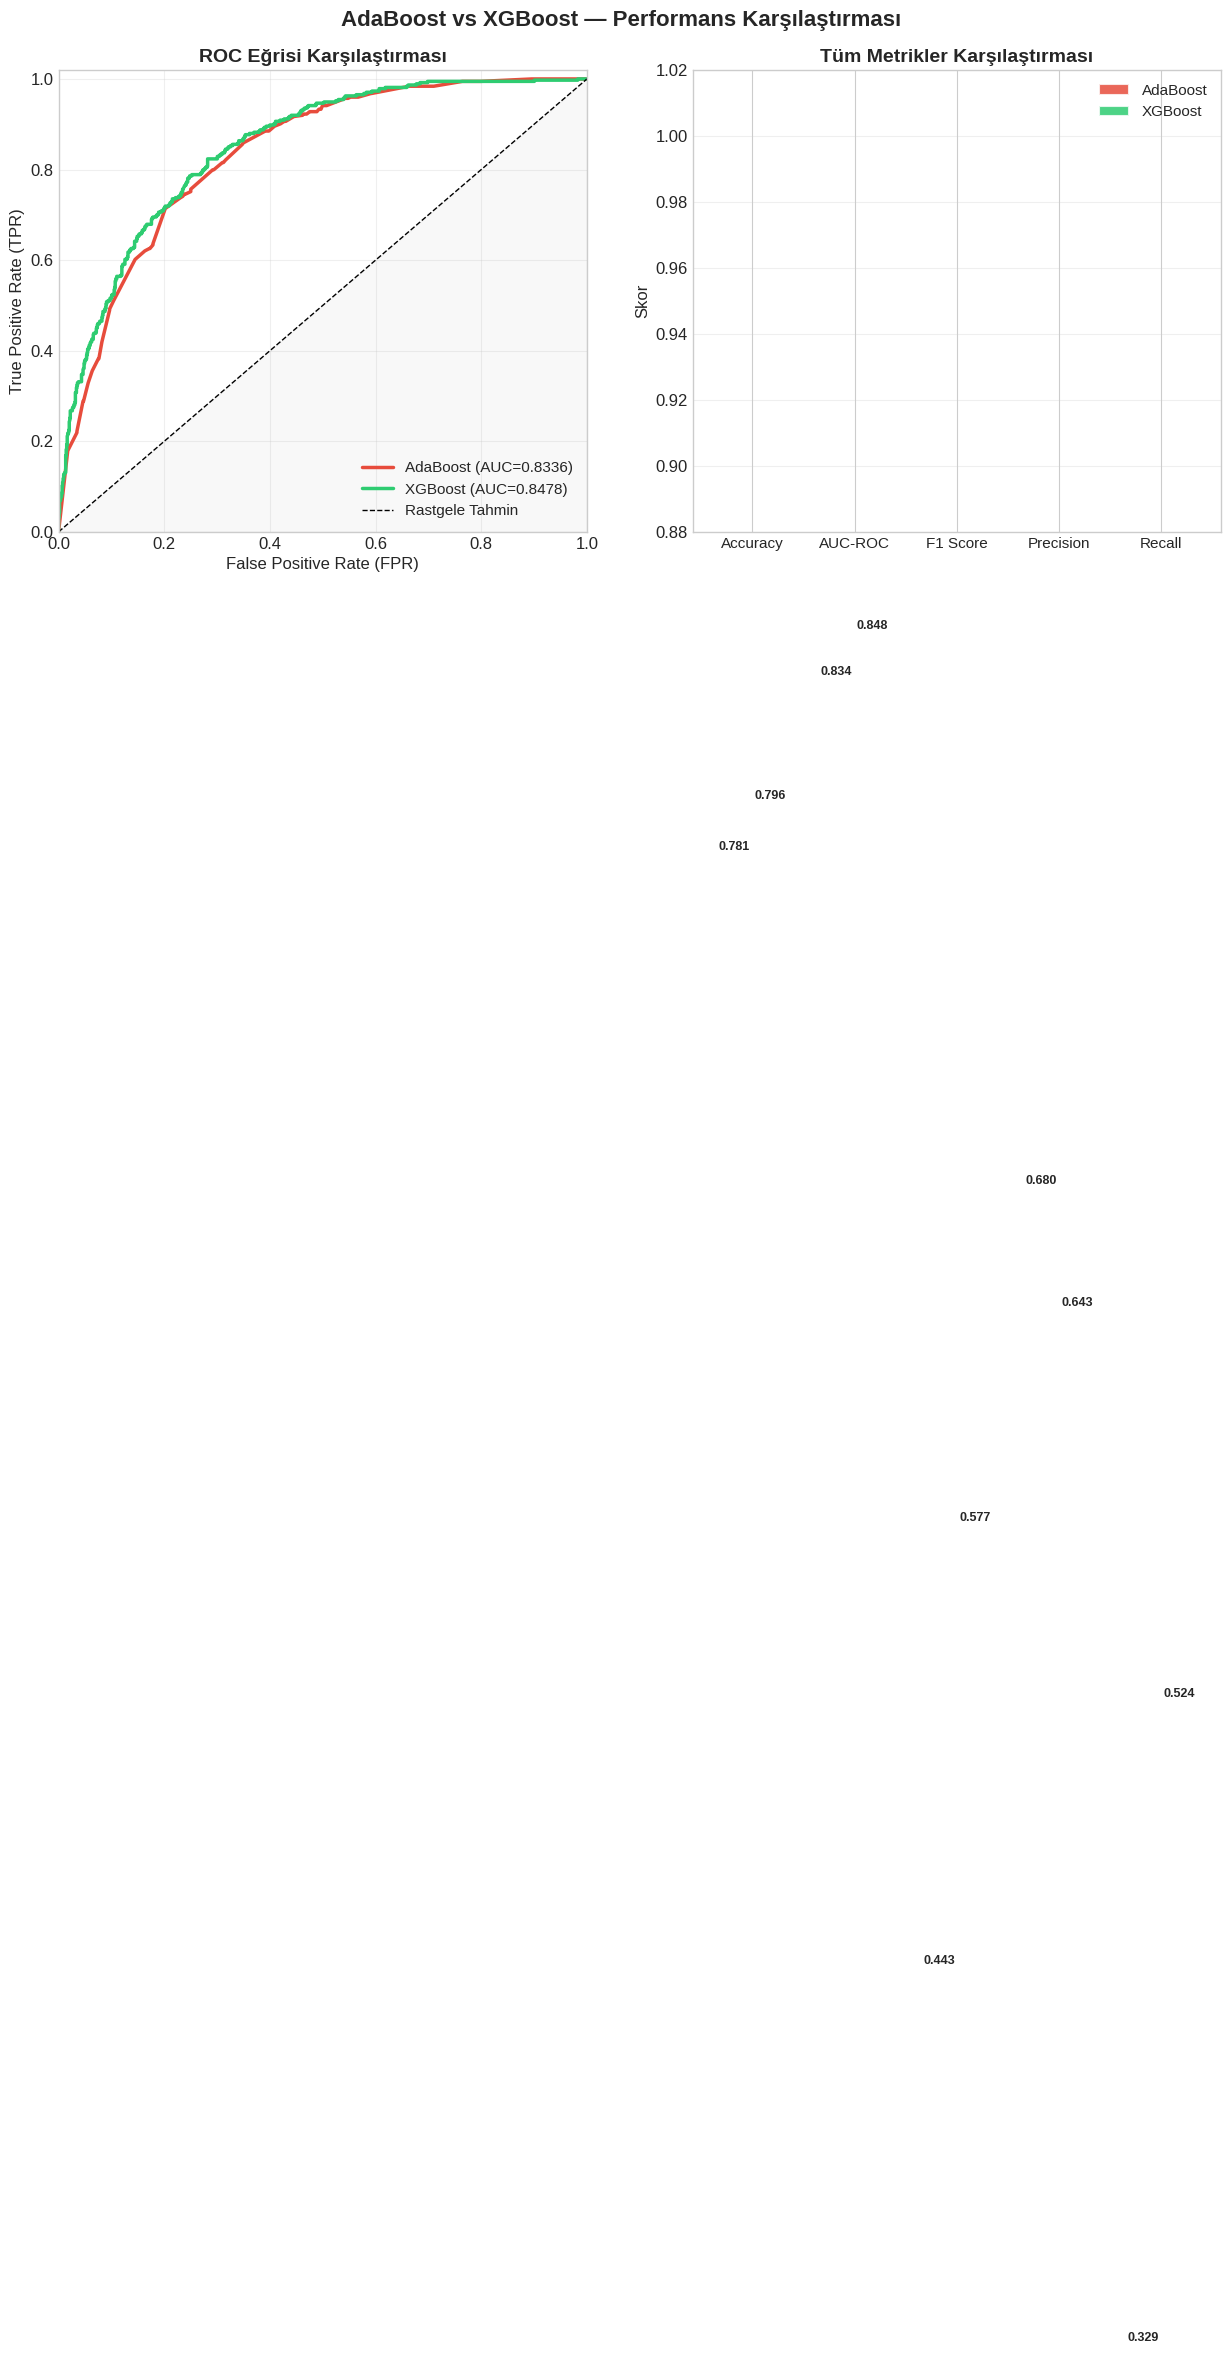

In [ ]:
# ─── Confusion Matrix Karşılaştırması ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title, color in zip(
    axes,
    [ada_pred, xgb_pred],
    ['🔴 AdaBoost', '🟢 XGBoost'],
    ['Reds', 'Greens']
):
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color,
        ax=ax,
        xticklabels=['Churn Yok', 'Churn Var'],
        yticklabels=['Churn Yok', 'Churn Var'],
        linewidths=2,
        linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )

    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Gerçek Sınıf', fontsize=11)
    ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11)

plt.suptitle('Confusion Matrix Karşılaştırması', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── ROC Eğrisi + Metrik Bar Grafiği ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for prob, label, color, acc, auc in [
    (ada_prob, 'AdaBoost', '#e74c3c', ada_acc, ada_auc),
    (xgb_prob, 'XGBoost',  '#2ecc71', xgb_acc, xgb_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{label} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Tahmin')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

metrics    = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall']
ada_scores = [ada_acc, ada_auc, ada_f1, ada_prec, ada_recall]
xgb_scores = [xgb_acc, xgb_auc, xgb_f1, xgb_prec, xgb_recall]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, ada_scores, width, label='AdaBoost',
                    color='#e74c3c', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = axes[1].bar(x + width/2, xgb_scores, width, label='XGBoost',
                    color='#2ecc71', alpha=0.85, edgecolor='white', linewidth=1.5)

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=11)
axes[1].set_ylabel('Skor', fontsize=12)
axes[1].set_title('Tüm Metrikler Karşılaştırması', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_ylim(0.88, 1.02)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('AdaBoost vs XGBoost — Performans Karşılaştırması',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


🔄 5-Fold Cross Validation Yapılıyor...

🔴 AdaBoost  CV Scores: [0.7892 0.7807 0.7715 0.7777 0.7841]
   Ortalama: 0.7806 ± 0.0060

🟢 XGBoost   CV Scores: [0.8155 0.8062 0.7885 0.8118 0.8018]
   Ortalama: 0.8048 ± 0.0094


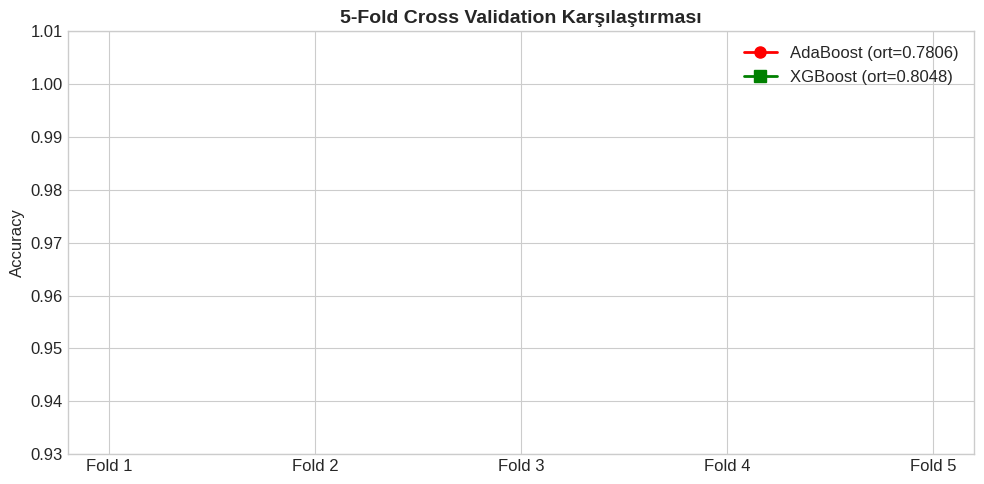

In [ ]:
# ─── 5-Fold Cross Validation ────────────────────────────────────────────────
print('\n🔄 5-Fold Cross Validation Yapılıyor...')
print('='*45)

ada_cv = cross_val_score(ada_model, X, y, cv=5, scoring='accuracy')
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

print(f'\n🔴 AdaBoost  CV Scores: {ada_cv.round(4)}')
print(f'   Ortalama: {ada_cv.mean():.4f} ± {ada_cv.std():.4f}')
print()
print(f'🟢 XGBoost   CV Scores: {xgb_cv.round(4)}')
print(f'   Ortalama: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)

ax.plot(x, ada_cv, 'r-o', markersize=8, linewidth=2,
        label=f'AdaBoost (ort={ada_cv.mean():.4f})')
ax.plot(x, xgb_cv, 'g-s', markersize=8, linewidth=2,
        label=f'XGBoost (ort={xgb_cv.mean():.4f})')

ax.fill_between(x,
                ada_cv.mean() - ada_cv.std(),
                ada_cv.mean() + ada_cv.std(),
                alpha=0.1, color='red')

ax.fill_between(x,
                xgb_cv.mean() - xgb_cv.std(),
                xgb_cv.mean() + xgb_cv.std(),
                alpha=0.1, color='green')

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Fold Cross Validation Karşılaştırması', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0.93, 1.01)

plt.tight_layout()
plt.show()

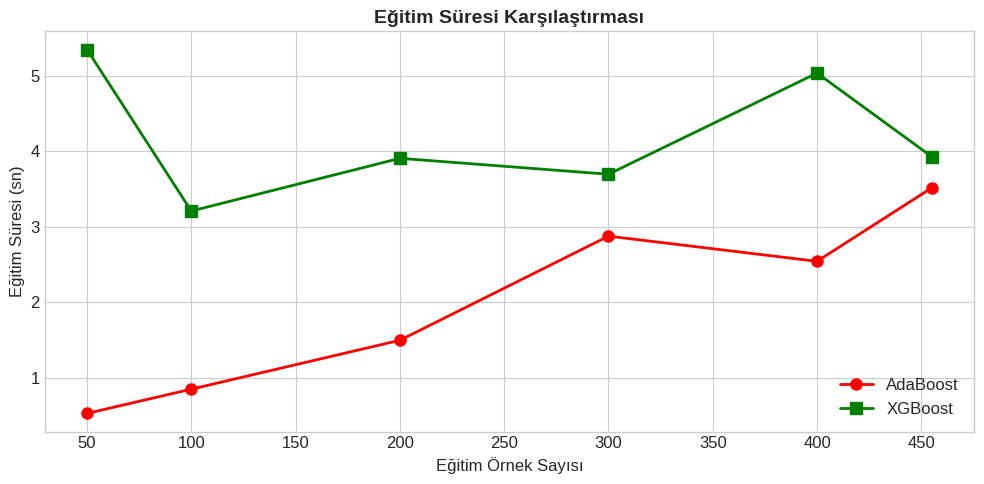


Full dataset eğitim süreleri:
   🔴 AdaBoost : 51.0248 sn
   🟢 XGBoost  : 28.6201 sn


In [ ]:
# ─── Farklı veri boyutlarında eğitim süresi analizi ──────────────────────────
sizes = [50, 100, 200, 300, 400, 455]
ada_times_list = []
xgb_times_list = []

for s in sizes:
    Xs = X_train.iloc[:s]
    ys = y_train.iloc[:s]

    m1 = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, learning_rate=0.1, algorithm='SAMME', random_state=42
    )
    t1 = time.time()
    m1.fit(Xs, ys)
    ada_times_list.append(time.time() - t1)

    m2 = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    t2 = time.time()
    m2.fit(Xs, ys)
    xgb_times_list.append(time.time() - t2)

plt.figure(figsize=(10, 5))
plt.plot(sizes, ada_times_list, 'r-o', markersize=8, linewidth=2, label='AdaBoost')
plt.plot(sizes, xgb_times_list, 'g-s', markersize=8, linewidth=2, label='XGBoost')
plt.xlabel('Eğitim Örnek Sayısı', fontsize=12)
plt.ylabel('Eğitim Süresi (sn)', fontsize=12)
plt.title('Eğitim Süresi Karşılaştırması', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nFull dataset eğitim süreleri:')
print(f'   🔴 AdaBoost : {ada_time:.4f} sn')
print(f'   🟢 XGBoost  : {xgb_time:.4f} sn')

In [ ]:
# ─── Tüm metrikleri tek tabloda özetle ──────────────────────────────────────
results_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall',
               'CV Ortalama', 'CV Std', 'Eğitim Süresi (sn)'],
    'AdaBoost 🔴': [
        f'{ada_acc:.4f}', f'{ada_auc:.4f}', f'{ada_f1:.4f}',
        f'{ada_prec:.4f}', f'{ada_recall:.4f}',
        f'{ada_cv.mean():.4f}', f'{ada_cv.std():.4f}',
        f'{ada_time:.4f}'
    ],
    'XGBoost 🟢': [
        f'{xgb_acc:.4f}', f'{xgb_auc:.4f}', f'{xgb_f1:.4f}',
        f'{xgb_prec:.4f}', f'{xgb_recall:.4f}',
        f'{xgb_cv.mean():.4f}', f'{xgb_cv.std():.4f}',
        f'{xgb_time:.4f}'
    ],
    'Kazanan': [
        '🟢 XGBoost' if xgb_acc    >= ada_acc    else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_auc    >= ada_auc    else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_f1     >= ada_f1     else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_prec   >= ada_prec   else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_recall >= ada_recall else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_cv.mean() >= ada_cv.mean() else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_cv.std()  <= ada_cv.std()  else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_time <= ada_time else '🔴 AdaBoost'
    ]
})

print('\n' + '='*65)
print('         🏆 ADABOOST vs XGBOOST — SONUÇ TABLOSU')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

xgb_wins = sum(1 for k in results_df['Kazanan'] if 'XGBoost' in k)
ada_wins = sum(1 for k in results_df['Kazanan'] if 'AdaBoost' in k)

print(f'\n📊 GENEL SONUÇ:')
print(f'   🟢 XGBoost kazandı  : {xgb_wins}/{len(results_df)} kategoride')
print(f'   🔴 AdaBoost kazandı : {ada_wins}/{len(results_df)} kategoride')


         🏆 ADABOOST vs XGBOOST — SONUÇ TABLOSU
            Metrik AdaBoost 🔴 XGBoost 🟢    Kazanan
          Accuracy     0.7807    0.7963  🟢 XGBoost
           AUC-ROC     0.8336    0.8478  🟢 XGBoost
          F1 Score     0.4432    0.5773  🟢 XGBoost
         Precision     0.6796    0.6426 🔴 AdaBoost
            Recall     0.3289    0.5241  🟢 XGBoost
       CV Ortalama     0.7806    0.8048  🟢 XGBoost
            CV Std     0.0060    0.0094 🔴 AdaBoost
Eğitim Süresi (sn)    51.0248   28.6201  🟢 XGBoost

📊 GENEL SONUÇ:
   🟢 XGBoost kazandı  : 6/8 kategoride
   🔴 AdaBoost kazandı : 2/8 kategoride
